# Creature Archetype Feature Exploration

This notebook explores creature archetypes to enhance feature engineering for the HP model.

## Archetypes to Detect:

### Primary Categories:
1. **Boss Monsters** - Legendary actions, highest CR in family, high mental stats, leader titles, ally interactions
2. **Lieutenants** - Mid-chain creatures, ally interactions, tactical features
3. **Minions** - Lowest in family chain, pack tactics, swarm mechanics
4. **Solo Challenges** - No legendary actions but multi-target/control abilities
5. **Enhanced Versions** - "Greater/Dire/Elder" variants

### Combat Role Categories:
6. **Artillery** - High ranged DPR, lower melee, lower HP
7. **Tanks** - High AC + HP, lower damage
8. **Controllers** - Condition imposers, battlefield manipulators
9. **Brutes** - High HP + damage, low AC, low speed
10. **Skirmishers** - Mobile, higher AC, lower HP
11. **Spellcasters** - Spellcasting features, versatile abilities
12. **Ambushers** - Stealth bonuses, surprise mechanics
13. **Swarms** - Explicit swarm creatures

Creatures can have multiple archetypes if probability > 0.2

In [19]:
# Detect execution context and set paths dynamically
import os

# Detect if running from notebook directory or project root
if os.path.basename(os.getcwd()) == 'notebooks':
    # Running from notebooks directory
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    OUTPUT_DIR = '../data'
else:
    # Running from project root or elsewhere
    DATA_DIR = 'data'
    PICKLED_MODELS_DIR = 'pickled_models'
    OUTPUT_DIR = 'data'

print(f"📁 Execution context detected:")
print(f"   Current directory: {os.getcwd()}")
print(f"   DATA_DIR: {DATA_DIR}")
print(f"   PICKLED_MODELS_DIR: {PICKLED_MODELS_DIR}")
print(f"   OUTPUT_DIR: {OUTPUT_DIR}")

# Verify paths exist
for path_name, path in [('DATA_DIR', DATA_DIR), ('PICKLED_MODELS_DIR', PICKLED_MODELS_DIR)]:
    if os.path.exists(path):
        print(f"   ✅ {path_name} exists")
    else:
        print(f"   ⚠️  {path_name} not found at {path}")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   DATA_DIR: data
   PICKLED_MODELS_DIR: pickled_models
   OUTPUT_DIR: data
   ✅ DATA_DIR exists
   ✅ PICKLED_MODELS_DIR exists


In [20]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import defaultdict, Counter
from difflib import SequenceMatcher

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [21]:
# Load the main dataset - merge raw data with engineered features
import os

# Load raw monster data (has text fields for parsing)
df_raw = pd.read_csv(f'{DATA_DIR}/dnd5e_monsters_from_json.csv')
print(f"Loaded {len(df_raw)} creatures from raw data")

# Load engineered features (has HP model features)
df_engineered = pd.read_csv(f'{DATA_DIR}/engineered_features.csv')
print(f"Loaded {len(df_engineered)} creatures from engineered features")

# Merge on Name
df = df_raw.merge(df_engineered, on='Name', how='inner', suffixes=('', '_eng'))

# Handle duplicate columns from merge
# Keep the raw data versions of: Type, Size, Challenge_Rating, HP, AC
duplicate_cols = ['Type_eng', 'Size_eng', 'Challenge_Rating_eng']
df = df.drop(columns=[col for col in duplicate_cols if col in df.columns], errors='ignore')

# Use cr_numeric from engineered features (it's the numeric version)
if 'cr_numeric' not in df.columns:
    # Fallback: convert Challenge_Rating to numeric
    cr_map = {'1/8': 0.125, '1/4': 0.25, '1/2': 0.5}
    df['cr_numeric'] = df['Challenge_Rating'].apply(
        lambda x: cr_map.get(str(x), float(x)) if pd.notna(x) else None
    )

# Ensure required columns exist with fallbacks
if 'has_flying' not in df.columns:
    df['has_flying'] = df['Speed'].str.contains('fly', case=False, na=False).astype(int)

if 'estimated_dpr' not in df.columns:
    print("⚠️ Warning: estimated_dpr not in engineered features, using 0 as placeholder")
    df['estimated_dpr'] = 0

print(f"\nMerged dataset: {len(df)} creatures")
print(f"\nColumns available:")
print(f"  - Raw text fields: Special_Abilities, Actions, Traits, Legendary_Actions")
print(f"  - Stats: STR, DEX, CON, INT, WIS, CHA")
print(f"  - Basic: HP, AC, Speed, Type")
print(f"  - Engineered: cr_numeric, has_flying, estimated_dpr")

# Show sample
df.head()

# Create alias: Special_Abilities is the same as Traits in this dataset
df['Special_Abilities'] = df['Traits']

Loaded 382 creatures from raw data
Loaded 382 creatures from engineered features

Merged dataset: 382 creatures

Columns available:
  - Raw text fields: Special_Abilities, Actions, Traits, Legendary_Actions
  - Stats: STR, DEX, CON, INT, WIS, CHA
  - Basic: HP, AC, Speed, Type
  - Engineered: cr_numeric, has_flying, estimated_dpr


## 1. Creature Family Detection

Identify chains of related monsters (e.g., Hobgoblin → Hobgoblin Captain → Hobgoblin Warlord)

In [22]:
def find_creature_families(df):
    """
    Group creatures into families based on:
    1. Name substring matching
    2. Type field matching
    """
    families = defaultdict(list)
    
    # Extract base names (remove common modifiers)
    modifiers = [
        'greater', 'lesser', 'dire', 'elder', 'young', 'ancient', 'adult',
        'captain', 'warlord', 'lord', 'king', 'queen', 'chief', 'boss',
        'champion', 'master', 'apprentice', 'knight', 'warrior', 'scout'
    ]
    
    for idx, row in df.iterrows():
        name = row['Name'].lower()
        cr = row['cr_numeric']
        creature_type = row.get('Type', '').lower()
        
        # Try to extract base name
        base_name = name
        for mod in modifiers:
            base_name = base_name.replace(mod, '').strip()
        
        # Create family key from base name
        family_key = base_name
        
        families[family_key].append({
            'name': row['Name'],
            'cr': cr,
            'type': creature_type,
            'index': idx
        })
    
    # Filter to families with 2+ members
    multi_member_families = {k: v for k, v in families.items() if len(v) >= 2}
    
    # Sort each family by CR
    for family in multi_member_families.values():
        family.sort(key=lambda x: x['cr'])
    
    return multi_member_families

# Find families
families = find_creature_families(df)

print(f"Found {len(families)} creature families with 2+ members")
print("\nExample families:")
for i, (family_name, members) in enumerate(list(families.items())[:10]):
    print(f"\n{family_name.title()}:")
    for m in members:
        print(f"  CR {m['cr']:>4}: {m['name']}")
    if i >= 9:
        break

Found 24 creature families with 2+ members

Example families:

Black Dragon:
  CR  7.0: Young Black Dragon
  CR 14.0: Adult Black Dragon
  CR 21.0: Ancient Black Dragon

Blue Dragon:
  CR  9.0: Young Blue Dragon
  CR 16.0: Adult Blue Dragon
  CR 23.0: Ancient Blue Dragon

Brass Dragon:
  CR  6.0: Young Brass Dragon
  CR 13.0: Adult Brass Dragon
  CR 20.0: Ancient Brass Dragon

Bronze Dragon:
  CR  8.0: Young Bronze Dragon
  CR 15.0: Adult Bronze Dragon
  CR 22.0: Ancient Bronze Dragon

Copper Dragon:
  CR  7.0: Young Copper Dragon
  CR 14.0: Adult Copper Dragon
  CR 21.0: Ancient Copper Dragon

Gold Dragon:
  CR 10.0: Young Gold Dragon
  CR 17.0: Adult Gold Dragon
  CR 24.0: Ancient Gold Dragon

Green Dragon:
  CR  8.0: Young Green Dragon
  CR 15.0: Adult Green Dragon
  CR 22.0: Ancient Green Dragon

Red Dragon:
  CR 10.0: Young Red Dragon
  CR 17.0: Adult Red Dragon
  CR 24.0: Ancient Red Dragon

Silver Dragon:
  CR  9.0: Young Silver Dragon
  CR 16.0: Adult Silver Dragon
  CR 23.0: A

In [23]:
# Create family position features
df['family_position'] = 'solo'  # Default: not in a multi-member family
df['family_size'] = 1
df['is_family_boss'] = 0
df['is_family_minion'] = 0
df['is_family_lieutenant'] = 0

for family_name, members in families.items():
    if len(members) < 2:
        continue
    
    family_size = len(members)
    
    for i, member in enumerate(members):
        idx = member['index']
        df.at[idx, 'family_size'] = family_size
        
        # Assign position
        if i == len(members) - 1:  # Highest CR
            df.at[idx, 'family_position'] = 'boss'
            df.at[idx, 'is_family_boss'] = 1
        elif i == 0:  # Lowest CR
            df.at[idx, 'family_position'] = 'minion'
            df.at[idx, 'is_family_minion'] = 1
        else:  # Middle
            df.at[idx, 'family_position'] = 'lieutenant'
            df.at[idx, 'is_family_lieutenant'] = 1

print("Family position distribution:")
print(df['family_position'].value_counts())

Family position distribution:
family_position
solo          322
boss           24
minion         24
lieutenant     12
Name: count, dtype: int64


## 2. Multi-Attack vs CR Analysis

Testing assumption: Higher CR creatures have more attacks in their multi-attack

In [24]:
import json
import re

def calculate_average_damage(damage_str):
    """Calculate average damage from dice notation like '2d8 + 5'"""
    if not damage_str:
        return 0
    
    total = 0
    # Match patterns like "2d8 + 5" or "1d10+3"
    patterns = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', str(damage_str))
    
    for match in patterns:
        num_dice = int(match[0])
        die_size = int(match[1])
        modifier = int(match[2]) if match[2] else 0
        avg = num_dice * (die_size + 1) / 2 + modifier
        total += avg
    
    return total


def count_multiattacks_from_json(actions_str):
    """
    Count number of attacks in multiattack action from JSON.
    Returns the total number of attacks mentioned in multiattack description.
    
    Borrowed and adapted from parse_dpr_from_json in three_tier_hp_model_v2.
    """
    if pd.isna(actions_str) or actions_str == '—':
        return 0
    
    try:
        actions = json.loads(actions_str)
    except (json.JSONDecodeError, TypeError):
        return 0
    
    # Find multiattack description
    multiattack_desc = None
    attack_names = []
    
    for action in actions:
        if not isinstance(action, dict):
            continue
        
        name = action.get('Name', '').lower()
        
        if name == 'multiattack':
            multiattack_desc = action.get('Desc', '').lower()
        elif 'Damage' in action:
            # Track attack names
            attack_names.append(name)
    
    if not multiattack_desc:
        return 0
    
    # Count total attacks mentioned in multiattack
    total_attacks = 0
    
    # Look for general patterns first
    general_patterns = [
        r'makes (\w+) attacks',  # "makes three attacks"
        r'(\w+) attacks',  # "three attacks"
    ]
    
    for pattern in general_patterns:
        match = re.search(pattern, multiattack_desc)
        if match:
            count_word = match.group(1).lower()
            number_map = {
                'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3,
                'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8
            }
            count = number_map.get(count_word, 0)
            if count == 0:
                try:
                    count = int(count_word)
                except ValueError:
                    count = 0
            
            if count > 0:
                return count
    
    # If general pattern didn't work, count specific attacks
    for attack_name in attack_names:
        patterns = [
            rf'(\w+)\s+{re.escape(attack_name)}\s+attacks?',
            rf'(\w+)\s+attacks?\s+with\s+(?:its\s+)?{re.escape(attack_name)}',
            rf'makes?\s+(\w+)\s+{re.escape(attack_name)}\s+attacks?',
        ]
        
        for pattern in patterns:
            match = re.search(pattern, multiattack_desc)
            if match:
                count_word = match.group(1).lower()
                number_map = {
                    'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3,
                    'four': 4, 'five': 5, 'six': 6, 'seven': 7, 'eight': 8
                }
                count = number_map.get(count_word, 0)
                if count == 0:
                    try:
                        count = int(count_word)
                    except ValueError:
                        count = 0
                
                if count > 0:
                    total_attacks += count
                    break
    
    return total_attacks if total_attacks > 0 else 0


# Apply function
df['multiattack_count'] = df['Actions'].apply(count_multiattacks_from_json)

print(f"Creatures with multiattack: {(df['multiattack_count'] > 0).sum()}")
print(f"\nMultiattack distribution:")
print(df[df['multiattack_count'] > 0]['multiattack_count'].value_counts().sort_index())

Creatures with multiattack: 132

Multiattack distribution:
multiattack_count
1     4
2    73
3    47
4     4
5     2
6     1
7     1
Name: count, dtype: int64


/tmp/ipykernel_38731/3176038994.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_multi['cr_bucket'] = pd.cut(df_with_multi['cr_numeric'],


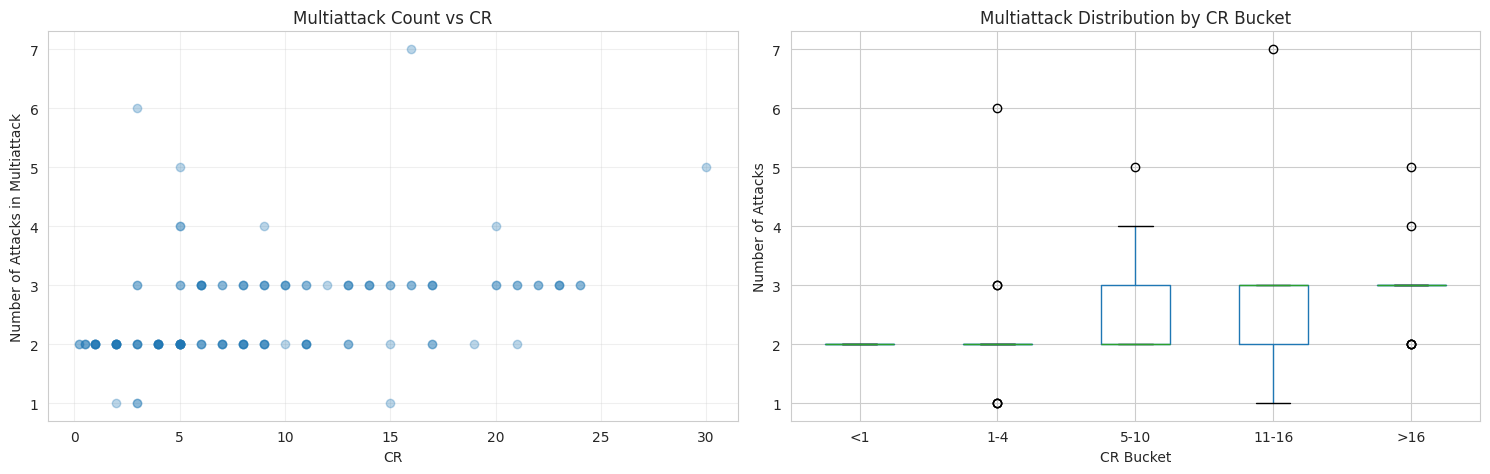


Multiattack count by CR bucket:
               mean  median       std  count
cr_bucket                                   
<1         2.000000     2.0  0.000000     12
1-4        2.111111     2.0  0.891556     27
5-10       2.529412     2.0  0.702935     51
11-16      2.772727     3.0  1.109776     22
>16        2.950000     3.0  0.686333     20


/tmp/ipykernel_38731/3176038994.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_with_multi.groupby('cr_bucket')['multiattack_count'].agg(['mean', 'median', 'std', 'count']))


In [25]:
# Visualize multiattack vs CR
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
df_with_multi = df[df['multiattack_count'] > 0]
axes[0].scatter(df_with_multi['cr_numeric'], df_with_multi['multiattack_count'], alpha=0.3)
axes[0].set_xlabel('CR')
axes[0].set_ylabel('Number of Attacks in Multiattack')
axes[0].set_title('Multiattack Count vs CR')
axes[0].grid(True, alpha=0.3)

# Boxplot by CR buckets
df_with_multi['cr_bucket'] = pd.cut(df_with_multi['cr_numeric'], 
                                      bins=[0, 1, 4, 10, 16, 30],
                                      labels=['<1', '1-4', '5-10', '11-16', '>16'])
df_with_multi.boxplot(column='multiattack_count', by='cr_bucket', ax=axes[1])
axes[1].set_xlabel('CR Bucket')
axes[1].set_ylabel('Number of Attacks')
axes[1].set_title('Multiattack Distribution by CR Bucket')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Statistical summary
print("\nMultiattack count by CR bucket:")
print(df_with_multi.groupby('cr_bucket')['multiattack_count'].agg(['mean', 'median', 'std', 'count']))

## 3. Archetype Detection Functions

Create probability scores for each archetype

In [26]:
import json

def has_legendary_actions(la_str):
    """Check if creature has legendary actions (properly handles JSON format)"""
    if pd.isna(la_str) or la_str == '—' or la_str.strip() == '':
        return False
    if la_str.startswith('['):
        try:
            data = json.loads(la_str)
            return len(data) > 0
        except:
            return False
    return False


def calculate_boss_score(row, df):
    """
    Boss Monster probability based on:
    - Has legendary actions (definite boss)
    - Highest CR in family
    - High mental stats relative to physical
    - Title words (lord, king, boss, etc.)
    - Ally interaction features
    """
    score = 0.0
    
    # Legendary actions = automatic boss
    if has_legendary_actions(row.get('Legendary_Actions', '')):
        return 1.0
    
    # Family position
    if row.get('is_family_boss', 0) == 1:
        score += 0.4
    
    # Title words
    boss_titles = ['lord', 'king', 'queen', 'boss', 'chief', 'warlord', 'master', 'emperor', 'matriarch', 'patriarch']
    name_lower = row['Name'].lower()
    if any(title in name_lower for title in boss_titles):
        score += 0.3
    
    # Mental stats > physical stats
    mental_stats = [row.get('INT', 10), row.get('WIS', 10), row.get('CHA', 10)]
    physical_stats = [row.get('STR', 10), row.get('DEX', 10), row.get('CON', 10)]
    if max(mental_stats) > max(physical_stats):
        score += 0.2
    
    # Ally interaction in abilities
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Actions', '')) + str(row.get('Traits', ''))
    ally_keywords = ['allies', 'ally', 'friendly creatures', 'creatures of its choice', 'command']
    if any(keyword in combined_abilities.lower() for keyword in ally_keywords):
        score += 0.2
    
    return min(score, 1.0)

# Apply
df['boss_score'] = df.apply(lambda row: calculate_boss_score(row, df), axis=1)
print(f"Creatures with boss_score > 0.2: {(df['boss_score'] > 0.2).sum()}")
print(f"\nTop 10 bosses:")
print(df.nlargest(10, 'boss_score')[['Name', 'cr_numeric', 'boss_score', 'family_position']])

Creatures with boss_score > 0.2: 55

Top 10 bosses:
                   Name  cr_numeric  boss_score family_position
0               Aboleth        10.0         1.0            solo
2    Adult Black Dragon        14.0         1.0      lieutenant
3     Adult Blue Dragon        16.0         1.0      lieutenant
4    Adult Brass Dragon        13.0         1.0      lieutenant
5   Adult Bronze Dragon        15.0         1.0      lieutenant
6   Adult Copper Dragon        14.0         1.0      lieutenant
7     Adult Gold Dragon        17.0         1.0      lieutenant
8    Adult Green Dragon        15.0         1.0      lieutenant
9      Adult Red Dragon        17.0         1.0      lieutenant
10  Adult Silver Dragon        16.0         1.0      lieutenant


In [27]:
def calculate_lieutenant_score(row):
    """
    Lieutenant probability based on:
    - Mid-chain family position
    - Title words (captain, champion, knight, etc.)
    - Ally interaction features
    """
    score = 0.0
    
    # Family position
    if row.get('is_family_lieutenant', 0) == 1:
        score += 0.5
    
    # Title words
    lieutenant_titles = ['captain', 'champion', 'knight', 'sergeant', 'veteran', 'elite']
    name_lower = row['Name'].lower()
    if any(title in name_lower for title in lieutenant_titles):
        score += 0.4
    
    # Ally interaction
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Actions', '')) + str(row.get('Traits', ''))
    ally_keywords = ['allies', 'ally', 'friendly creatures']
    if any(keyword in combined_abilities.lower() for keyword in ally_keywords):
        score += 0.3
    
    return min(score, 1.0)

df['lieutenant_score'] = df.apply(calculate_lieutenant_score, axis=1)
print(f"Creatures with lieutenant_score > 0.2: {(df['lieutenant_score'] > 0.2).sum()}")
print(f"\nTop 10 lieutenants:")
print(df.nlargest(10, 'lieutenant_score')[['Name', 'cr_numeric', 'lieutenant_score', 'family_position']])

Creatures with lieutenant_score > 0.2: 102

Top 10 lieutenants:
                    Name  cr_numeric  lieutenant_score family_position
5    Adult Bronze Dragon        15.0               0.8      lieutenant
7      Adult Gold Dragon        17.0               0.8      lieutenant
10   Adult Silver Dragon        16.0               0.8      lieutenant
11    Adult White Dragon        13.0               0.8      lieutenant
196    Hobgoblin Warrior         0.5               0.8      lieutenant
195    Hobgoblin Captain         3.0               0.7            boss
2     Adult Black Dragon        14.0               0.5      lieutenant
3      Adult Blue Dragon        16.0               0.5      lieutenant
4     Adult Brass Dragon        13.0               0.5      lieutenant
6    Adult Copper Dragon        14.0               0.5      lieutenant


In [28]:
def calculate_minion_score(row):
    """
    Minion probability based on:
    - Lowest in family chain
    - Pack tactics feature
    - Low CR relative to family
    """
    score = 0.0
    
    # Family position
    if row.get('is_family_minion', 0) == 1:
        score += 0.5
    
    # Pack tactics
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Traits', ''))
    if 'pack tactics' in combined_abilities.lower():
        score += 0.5
    
    return min(score, 1.0)

df['minion_score'] = df.apply(calculate_minion_score, axis=1)
print(f"Creatures with minion_score > 0.2: {(df['minion_score'] > 0.2).sum()}")
print(f"\nTop 10 minions:")
print(df.nlargest(10, 'minion_score')[['Name', 'cr_numeric', 'minion_score', 'family_position']])

Creatures with minion_score > 0.2: 43

Top 10 minions:
                   Name  cr_numeric  minion_score family_position
211              Kobold       0.125           1.0          minion
334               Tough       0.500           1.0          minion
366                Wolf       0.250           1.0          minion
44               Baboon       0.000           0.5            solo
47               Bandit       0.125           0.5          minion
59           Blood Hawk       0.125           0.5            solo
66              Bugbear       1.000           0.5          minion
98            Dire Wolf       1.000           0.5            boss
99   Diseased Giant Rat       0.125           0.5            solo
151           Giant Rat       0.125           0.5            solo


In [29]:
def calculate_solo_challenge_score(row):
    """
    Solo Challenge probability based on:
    - NO legendary actions
    - Multi-target abilities
    - AOE abilities (radius, cone, cube, line)
    - Swallow/incapacitate abilities
    - Abilities affecting "up to X" creatures
    """
    # Must NOT have legendary actions
    if has_legendary_actions(row.get('Legendary_Actions', '')):
        return 0.0
    
    score = 0.0
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Actions', ''))
    
    # AOE abilities
    aoe_patterns = [r'\d+-foot radius', r'\d+-foot cone', r'\d+-foot cube', r'\d+-foot line']
    if any(re.search(pattern, combined_abilities, re.IGNORECASE) for pattern in aoe_patterns):
        score += 0.4
    
    # Multi-target ("up to X")
    if re.search(r'up to \d+', combined_abilities, re.IGNORECASE):
        score += 0.3
    
    # Swallow mechanics
    if 'swallow' in combined_abilities.lower():
        score += 0.4
    
    # "All creatures" abilities
    if 'all creatures' in combined_abilities.lower():
        score += 0.3
    
    return min(score, 1.0)

df['solo_challenge_score'] = df.apply(calculate_solo_challenge_score, axis=1)
print(f"Creatures with solo_challenge_score > 0.2: {(df['solo_challenge_score'] > 0.2).sum()}")
print(f"\nTop 10 solo challenges:")
print(df.nlargest(10, 'solo_challenge_score')[['Name', 'cr_numeric', 'solo_challenge_score']])

Creatures with solo_challenge_score > 0.2: 63

Top 10 solo challenges:
                      Name  cr_numeric  solo_challenge_score
93              Darkmantle        0.50                   0.7
104          Dragon Turtle       17.00                   0.7
143             Giant Frog        0.25                   0.7
157             Giant Toad        1.00                   0.7
42                    Azer        2.00                   0.4
43           Azer Sentinel        2.00                   0.4
53                   Behir       11.00                   0.4
56   Black Dragon Wyrmling        2.00                   0.4
60    Blue Dragon Wyrmling        3.00                   0.4
63   Brass Dragon Wyrmling        1.00                   0.4


In [30]:
def calculate_enhanced_version_score(row):
    """
    Enhanced Version probability based on:
    - Name contains: greater, dire, elder, ancient, enhanced
    """
    score = 0.0
    
    enhanced_words = ['greater', 'dire', 'elder', 'ancient', 'enhanced', 'improved', 'superior']
    name_lower = row['Name'].lower()
    
    if any(word in name_lower for word in enhanced_words):
        score = 0.8
    
    return score

df['enhanced_version_score'] = df.apply(calculate_enhanced_version_score, axis=1)
print(f"Creatures with enhanced_version_score > 0.2: {(df['enhanced_version_score'] > 0.2).sum()}")
print(f"\nEnhanced versions:")
print(df[df['enhanced_version_score'] > 0.2][['Name', 'cr_numeric', 'enhanced_version_score']].head(20))

Creatures with enhanced_version_score > 0.2: 11

Enhanced versions:
                     Name  cr_numeric  enhanced_version_score
14   Ancient Black Dragon        21.0                     0.8
15    Ancient Blue Dragon        23.0                     0.8
16   Ancient Brass Dragon        20.0                     0.8
17  Ancient Bronze Dragon        22.0                     0.8
18  Ancient Copper Dragon        21.0                     0.8
19    Ancient Gold Dragon        24.0                     0.8
20   Ancient Green Dragon        22.0                     0.8
21     Ancient Red Dragon        24.0                     0.8
22  Ancient Silver Dragon        23.0                     0.8
23   Ancient White Dragon        20.0                     0.8
98              Dire Wolf         1.0                     0.8


## 4. Combat Role Archetypes

In [31]:
# First, need to calculate some relative stats
# Group by CR and calculate percentiles

def calculate_cr_percentile(df, column, cr_value, value):
    """
    Calculate percentile of a value within its CR group
    """
    if pd.isna(value):
        return 0.5
    
    cr_group = df[abs(df['cr_numeric'] - cr_value) < 2][column].dropna()
    if len(cr_group) == 0:
        return 0.5
    
    percentile = (cr_group < value).sum() / len(cr_group)
    return percentile

# Calculate percentiles for key stats (this may take a moment)
print("Calculating CR-relative percentiles...")
for col in ['HP', 'AC', 'estimated_dpr', 'Speed']:
    if col in df.columns:
        df[f'{col}_percentile'] = df.apply(
            lambda row: calculate_cr_percentile(df, col, row['cr_numeric'], row[col]), 
            axis=1
        )
        print(f"  Calculated {col}_percentile")

print("Done!")

Calculating CR-relative percentiles...
  Calculated HP_percentile
  Calculated AC_percentile
  Calculated estimated_dpr_percentile
  Calculated Speed_percentile
Done!


In [32]:
def calculate_brute_score(row):
    """
    Brute: High HP + damage, low AC, low speed
    """
    score = 0.0
    
    # High HP (>75th percentile)
    if row.get('HP_percentile', 0.5) > 0.75:
        score += 0.3
    
    # High damage (>75th percentile)
    if row.get('estimated_dpr_percentile', 0.5) > 0.75:
        score += 0.3
    
    # Low AC (<25th percentile)
    if row.get('AC_percentile', 0.5) < 0.25:
        score += 0.2
    
    # Low speed (<25th percentile)
    if row.get('Speed_percentile', 0.5) < 0.25:
        score += 0.2
    
    return min(score, 1.0)

df['brute_score'] = df.apply(calculate_brute_score, axis=1)
print(f"Creatures with brute_score > 0.2: {(df['brute_score'] > 0.2).sum()}")
print(f"\nTop 10 brutes:")
print(df.nlargest(10, 'brute_score')[['Name', 'cr_numeric', 'brute_score', 'HP_percentile', 'AC_percentile']])

Creatures with brute_score > 0.2: 167

Top 10 brutes:
              Name  cr_numeric  brute_score  HP_percentile  AC_percentile
214          Lamia         4.0          1.0       0.971831       0.183099
280            Roc        11.0          1.0       0.875000       0.062500
35        Archelon         4.0          0.8       0.873239       0.704225
37        Assassin         8.0          0.8       0.916667       0.333333
40   Awakened Tree         2.0          0.8       0.826923       0.557692
104  Dragon Turtle        17.0          0.8       0.900000       0.800000
119          Ettin         4.0          0.8       0.802817       0.112676
179        Griffon         2.0          0.8       0.807692       0.173077
261   Plesiosaurus         2.0          0.8       0.875000       0.557692
269    Purple Worm        15.0          0.8       0.833333       0.083333


In [33]:
def calculate_tank_score(row):
    """
    Tank: High AC + HP, lower damage
    """
    score = 0.0
    
    # High HP (>75th percentile)
    if row.get('HP_percentile', 0.5) > 0.75:
        score += 0.3
    
    # High AC (>75th percentile)
    if row.get('AC_percentile', 0.5) > 0.75:
        score += 0.4
    
    # Low damage (<50th percentile)
    if row.get('estimated_dpr_percentile', 0.5) < 0.5:
        score += 0.2
    
    return min(score, 1.0)

df['tank_score'] = df.apply(calculate_tank_score, axis=1)
print(f"Creatures with tank_score > 0.2: {(df['tank_score'] > 0.2).sum()}")
print(f"\nTop 10 tanks:")
print(df.nlargest(10, 'tank_score')[['Name', 'cr_numeric', 'tank_score', 'HP_percentile', 'AC_percentile']])

Creatures with tank_score > 0.2: 140

Top 10 tanks:
                       Name  cr_numeric  tank_score  HP_percentile  \
87                   Couatl       4.000         0.9       0.985915   
102         Draconic Spirit       0.000         0.9       0.901163   
163       Gibbering Mouther       2.000         0.9       0.865385   
169                  Goblin       0.250         0.9       0.932127   
177               Green Hag       3.000         0.9       0.882979   
241                   Noble       0.125         0.9       0.977376   
281                   Roper       5.000         0.9       0.872727   
27   Animated Object (Huge)       0.000         0.7       0.848837   
48           Bandit Captain       2.000         0.7       0.855769   
57            Black Pudding       4.000         0.7       0.802817   

     AC_percentile  
87        0.915493  
102       0.941860  
163       0.990385  
169       0.814480  
177       0.797872  
241       0.796380  
281       0.945455  
27       

In [34]:
def calculate_skirmisher_score(row):
    """
    Skirmisher: High speed/mobility, higher AC, lower HP
    """
    score = 0.0
    
    # High speed (>75th percentile)
    if row.get('Speed_percentile', 0.5) > 0.75:
        score += 0.3
    
    # Has fly/teleport
    if row.get('has_flying', 0) == 1:
        score += 0.3
    
    # High AC (>60th percentile)
    if row.get('AC_percentile', 0.5) > 0.6:
        score += 0.2
    
    # Lower HP (<40th percentile)
    if row.get('HP_percentile', 0.5) < 0.4:
        score += 0.2
    
    return min(score, 1.0)

df['skirmisher_score'] = df.apply(calculate_skirmisher_score, axis=1)
print(f"Creatures with skirmisher_score > 0.2: {(df['skirmisher_score'] > 0.2).sum()}")
print(f"\nTop 10 skirmishers:")
print(df.nlargest(10, 'skirmisher_score')[['Name', 'cr_numeric', 'skirmisher_score', 'Speed_percentile', 'has_flying']])

Creatures with skirmisher_score > 0.2: 194

Top 10 skirmishers:
                      Name  cr_numeric  skirmisher_score  Speed_percentile  \
26   Animated Flying Sword        0.25               1.0          0.846154   
38         Avatar of Death        0.00               1.0          0.970930   
371     Young Black Dragon        7.00               1.0          0.814815   
377     Young Green Dragon        8.00               1.0          0.833333   
51                     Bat        0.00               0.8          0.866279   
146           Giant Insect        0.00               0.8          0.790698   
149              Giant Owl        0.25               0.8          0.877828   
206      Invisible Stalker        6.00               0.8          0.953488   
251                    Owl        0.00               0.8          0.877907   
302                  Solar       21.00               0.8          0.888889   

     has_flying  
26            1  
38            1  
371           1  
377  

In [35]:
def calculate_spellcaster_score(row):
    """
    Spellcaster: Has spellcasting or innate spellcasting features
    """
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Traits', ''))
    
    if 'spellcasting' in combined_abilities.lower():
        # Count spell levels or slots to distinguish full vs limited
        spell_count = combined_abilities.lower().count('level')
        if spell_count >= 5:
            return 0.9  # Full caster
        else:
            return 0.6  # Limited caster
    
    return 0.0

df['spellcaster_score'] = df.apply(calculate_spellcaster_score, axis=1)
print(f"Creatures with spellcaster_score > 0.2: {(df['spellcaster_score'] > 0.2).sum()}")
print(f"\nTop 10 spellcasters:")
print(df.nlargest(10, 'spellcaster_score')[['Name', 'cr_numeric', 'spellcaster_score']])

Creatures with spellcaster_score > 0.2: 38

Top 10 spellcasters:
              Name  cr_numeric  spellcaster_score
24     Androsphinx        17.0                0.9
36        Archmage        12.0                0.9
90    Cult Fanatic         2.0                0.9
108          Druid         2.0                0.9
183  Guardian Naga        10.0                0.9
184     Gynosphinx        11.0                0.9
216           Lich        21.0                0.9
220           Mage         6.0                0.9
237     Mummy Lord        15.0                0.9
265         Priest         2.0                0.9


In [36]:
def calculate_controller_score(row):
    """
    Controller: Imposes conditions, manipulates battlefield
    """
    score = 0.0
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Actions', ''))
    
    # Condition imposing
    conditions = ['restrained', 'paralyzed', 'stunned', 'charmed', 'frightened', 'prone', 'grappled']
    condition_count = sum(1 for c in conditions if c in combined_abilities.lower())
    score += min(condition_count * 0.2, 0.6)
    
    # Battlefield manipulation
    if any(word in combined_abilities.lower() for word in ['difficult terrain', 'web', 'darkness', 'fog']):
        score += 0.3
    
    return min(score, 1.0)

df['controller_score'] = df.apply(calculate_controller_score, axis=1)
print(f"Creatures with controller_score > 0.2: {(df['controller_score'] > 0.2).sum()}")
print(f"\nTop 10 controllers:")
print(df.nlargest(10, 'controller_score')[['Name', 'cr_numeric', 'controller_score']])

Creatures with controller_score > 0.2: 73

Top 10 controllers:
                Name  cr_numeric  controller_score
213           Kraken       23.00               0.9
77       Chain Devil        8.00               0.7
130            Ghost        4.00               0.7
156     Giant Spider        1.00               0.7
24       Androsphinx       17.00               0.6
53             Behir       11.00               0.6
94         Death Dog        1.00               0.6
119            Ettin        4.00               0.6
139  Giant Crocodile        5.00               0.6
143       Giant Frog        0.25               0.6


In [37]:
def calculate_ambusher_score(row):
    """
    Ambusher: Stealth bonuses, surprise mechanics
    """
    score = 0.0
    combined_abilities = str(row.get('Special_Abilities', '')) + str(row.get('Actions', '')) + str(row.get('Traits', ''))
    
    # Stealth-related
    if 'stealth' in combined_abilities.lower():
        score += 0.4
    
    # Surprise mechanics
    surprise_keywords = ['surprise', 'ambush', 'unseen', 'invisible', 'hidden']
    if any(keyword in combined_abilities.lower() for keyword in surprise_keywords):
        score += 0.4
    
    # Advantage on first turn
    if 'first turn' in combined_abilities.lower() or 'surprised creature' in combined_abilities.lower():
        score += 0.3
    
    return min(score, 1.0)

df['ambusher_score'] = df.apply(calculate_ambusher_score, axis=1)
print(f"Creatures with ambusher_score > 0.2: {(df['ambusher_score'] > 0.2).sum()}")
print(f"\nTop 10 ambushers:")
print(df.nlargest(10, 'ambusher_score')[['Name', 'cr_numeric', 'ambusher_score']])

Creatures with ambusher_score > 0.2: 23

Top 10 ambushers:
                         Name  cr_numeric  ambusher_score
37                   Assassin         8.0             0.7
50                   Basilisk         3.0             0.4
66                    Bugbear         1.0             0.4
95   Deep Gnome (Svirfneblin)         0.5             0.4
101              Doppelganger         3.0             0.4
110                   Duergar         1.0             0.4
128           Gelatinous Cube         2.0             0.4
148             Giant Octopus         1.0             0.4
177                 Green Hag         3.0             0.4
178                     Grick         2.0             0.4


In [38]:
def calculate_swarm_score(row):
    """
    Swarm: Explicit swarm creatures
    """
    name_lower = row['Name'].lower()
    if 'swarm' in name_lower:
        return 0.9
    return 0.0

df['swarm_score'] = df.apply(calculate_swarm_score, axis=1)
print(f"Creatures with swarm_score > 0.2: {(df['swarm_score'] > 0.2).sum()}")
print(f"\nSwarm creatures:")
print(df[df['swarm_score'] > 0.2][['Name', 'cr_numeric', 'swarm_score']])

Creatures with swarm_score > 0.2: 13

Swarm creatures:
                          Name  cr_numeric  swarm_score
318              Swarm of Bats        0.25          0.9
319           Swarm of Beetles        0.50          0.9
320        Swarm of Centipedes        0.50          0.9
321    Swarm of Crawling Claws        3.00          0.9
322           Swarm of Insects        0.50          0.9
323          Swarm of Piranhas        1.00          0.9
324  Swarm of Poisonous Snakes        2.00          0.9
325          Swarm of Quippers        1.00          0.9
326              Swarm of Rats        0.25          0.9
327            Swarm of Ravens        0.25          0.9
328           Swarm of Spiders        0.50          0.9
329   Swarm of Venomous Snakes        2.00          0.9
330             Swarm of Wasps        0.50          0.9


## 5. Archetype Summary

Assign creature types (multiple allowed if score > 0.2)

In [39]:
# Collect all archetype scores
archetype_columns = [
    'boss_score', 'lieutenant_score', 'minion_score', 'solo_challenge_score', 'enhanced_version_score',
    'brute_score', 'tank_score', 'skirmisher_score', 'spellcaster_score', 'controller_score',
    'ambusher_score', 'swarm_score'
]

# Create archetype labels
def get_archetypes(row, threshold=0.2):
    archetypes = []
    archetype_names = {
        'boss_score': 'Boss',
        'lieutenant_score': 'Lieutenant',
        'minion_score': 'Minion',
        'solo_challenge_score': 'Solo Challenge',
        'enhanced_version_score': 'Enhanced',
        'brute_score': 'Brute',
        'tank_score': 'Tank',
        'skirmisher_score': 'Skirmisher',
        'spellcaster_score': 'Spellcaster',
        'controller_score': 'Controller',
        'ambusher_score': 'Ambusher',
        'swarm_score': 'Swarm'
    }
    
    for col in archetype_columns:
        if row.get(col, 0) > threshold:
            archetypes.append(archetype_names[col])
    
    return ', '.join(archetypes) if archetypes else 'Standard'

df['archetypes'] = df.apply(get_archetypes, axis=1)

print("Archetype distribution:")
print(df['archetypes'].value_counts().head(20))

print(f"\nCreatures with multiple archetypes: {(df['archetypes'].str.contains(',')).sum()}")

Archetype distribution:
archetypes
Skirmisher                                     31
Standard                                       26
Brute                                          21
Brute, Tank                                    19
Brute, Skirmisher                              15
Tank, Skirmisher                               14
Brute, Tank, Skirmisher                        12
Solo Challenge, Tank, Skirmisher               11
Controller                                      9
Boss, Lieutenant, Skirmisher                    8
Minion, Solo Challenge, Skirmisher              8
Lieutenant, Minion                              6
Swarm                                           6
Brute, Skirmisher, Controller                   5
Brute, Tank, Controller                         5
Boss, Lieutenant, Brute, Tank                   5
Boss, Lieutenant, Enhanced, Skirmisher          4
Solo Challenge, Brute, Tank                     4
Lieutenant, Minion, Brute, Tank                 4
Lieutenant, Min

## 6. Visualization

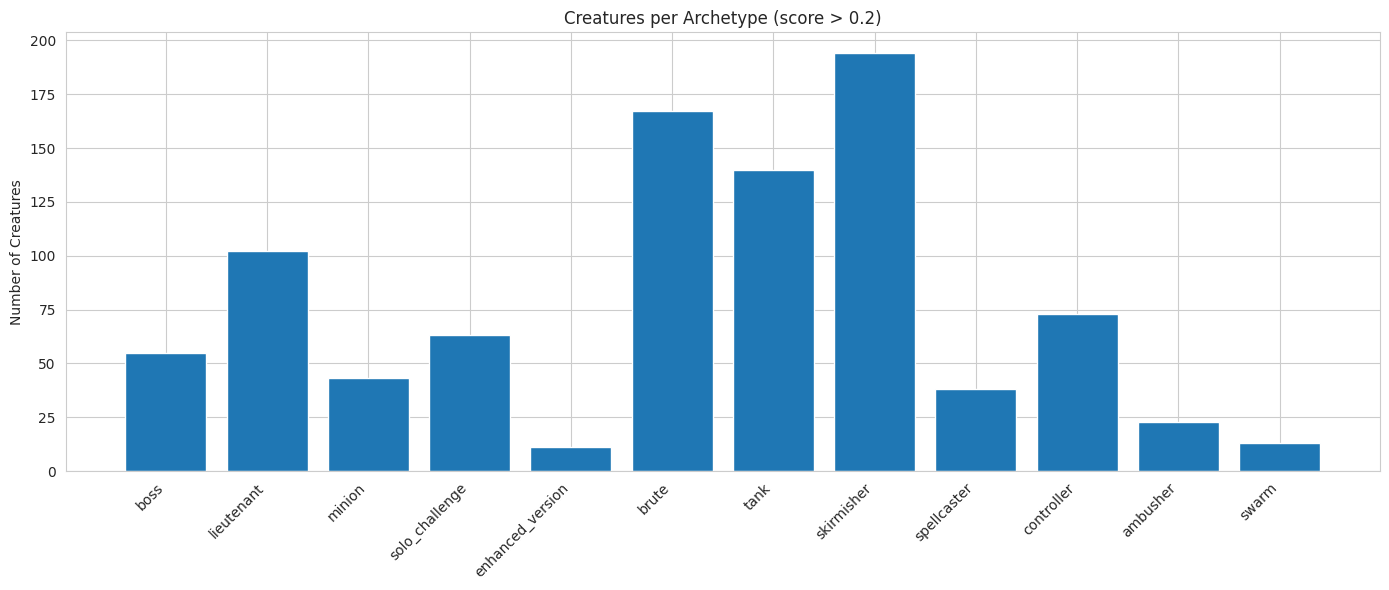

boss                :   55 creatures
lieutenant          :  102 creatures
minion              :   43 creatures
solo_challenge      :   63 creatures
enhanced_version    :   11 creatures
brute               :  167 creatures
tank                :  140 creatures
skirmisher          :  194 creatures
spellcaster         :   38 creatures
controller          :   73 creatures
ambusher            :   23 creatures
swarm               :   13 creatures


In [40]:
# Count creatures per archetype
archetype_counts = {}
for col in archetype_columns:
    archetype_counts[col.replace('_score', '')] = (df[col] > 0.2).sum()

# Plot
plt.figure(figsize=(14, 6))
plt.bar(range(len(archetype_counts)), list(archetype_counts.values()))
plt.xticks(range(len(archetype_counts)), list(archetype_counts.keys()), rotation=45, ha='right')
plt.ylabel('Number of Creatures')
plt.title('Creatures per Archetype (score > 0.2)')
plt.tight_layout()
plt.show()

for name, count in archetype_counts.items():
    print(f"{name:20s}: {count:4d} creatures")

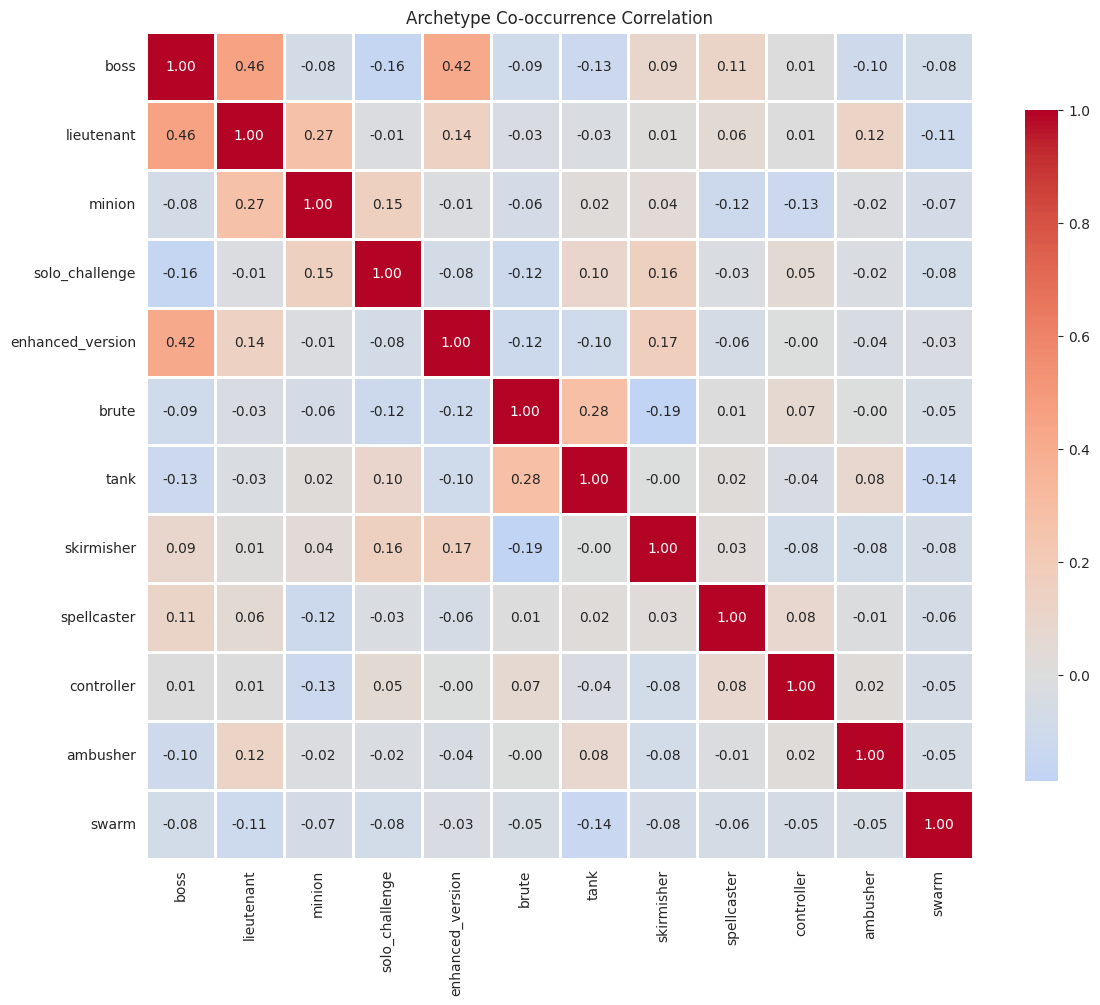

In [41]:
# Heatmap of archetype co-occurrence
import numpy as np

# Create binary matrix
archetype_matrix = df[archetype_columns] > 0.2
archetype_matrix.columns = [c.replace('_score', '') for c in archetype_columns]

# Calculate correlation
correlation = archetype_matrix.astype(int).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Archetype Co-occurrence Correlation')
plt.tight_layout()
plt.show()

## 7. Example Creatures per Archetype

In [42]:
# Show examples for each archetype
archetype_names = {
    'boss_score': 'Boss Monsters',
    'lieutenant_score': 'Lieutenants',
    'minion_score': 'Minions',
    'solo_challenge_score': 'Solo Challenges',
    'brute_score': 'Brutes',
    'tank_score': 'Tanks',
    'skirmisher_score': 'Skirmishers',
    'spellcaster_score': 'Spellcasters',
    'controller_score': 'Controllers',
    'ambusher_score': 'Ambushers'
}

for score_col, display_name in archetype_names.items():
    print(f"\n{'='*80}")
    print(f"{display_name}")
    print('='*80)
    
    examples = df[df[score_col] > 0.2].nlargest(5, score_col)
    for _, creature in examples.iterrows():
        print(f"\n{creature['Name']} (CR {creature['cr_numeric']})")
        print(f"  Score: {creature[score_col]:.2f}")
        print(f"  All archetypes: {creature['archetypes']}")


Boss Monsters

Aboleth (CR 10.0)
  Score: 1.00
  All archetypes: Boss, Lieutenant, Brute

Adult Black Dragon (CR 14.0)
  Score: 1.00
  All archetypes: Boss, Lieutenant, Tank, Skirmisher

Adult Blue Dragon (CR 16.0)
  Score: 1.00
  All archetypes: Boss, Lieutenant, Skirmisher

Adult Brass Dragon (CR 13.0)
  Score: 1.00
  All archetypes: Boss, Lieutenant, Skirmisher

Adult Bronze Dragon (CR 15.0)
  Score: 1.00
  All archetypes: Boss, Lieutenant, Skirmisher

Lieutenants

Adult Bronze Dragon (CR 15.0)
  Score: 0.80
  All archetypes: Boss, Lieutenant, Skirmisher

Adult Gold Dragon (CR 17.0)
  Score: 0.80
  All archetypes: Boss, Lieutenant, Skirmisher

Adult Silver Dragon (CR 16.0)
  Score: 0.80
  All archetypes: Boss, Lieutenant, Skirmisher, Controller

Adult White Dragon (CR 13.0)
  Score: 0.80
  All archetypes: Boss, Lieutenant, Skirmisher, Controller

Hobgoblin Warrior (CR 0.5)
  Score: 0.80
  All archetypes: Lieutenant, Minion, Brute, Tank, Skirmisher

Minions

Kobold (CR 0.125)
  Scor

## 8. Export Results

In [43]:
# Save archetype scores to CSV
output_cols = ['Name', 'cr_numeric', 'HP', 'AC'] + archetype_columns + ['archetypes', 'family_position', 'family_size']
output_df = df[output_cols]

output_df.to_csv(f'{OUTPUT_DIR}/creature_archetypes.csv', index=False)
print(f"✅ Saved archetype data to data/creature_archetypes.csv")
print(f"   {len(output_df)} creatures with {len(archetype_columns)} archetype scores")

✅ Saved archetype data to data/creature_archetypes.csv
   382 creatures with 12 archetype scores


## 9. Correlation with HP Model Residuals

Check if any archetypes correlate with prediction errors

In [44]:
# Try to load predictions from HP model
try:
    model_results = pd.read_csv(f'{DATA_DIR}/hp_predictions_with_contributions.csv')
    
    # Merge with archetypes
    merged = df[['Name'] + archetype_columns].merge(model_results[['Name', 'actual_hp', 'predicted_hp']], on='Name', how='inner')
    merged['residual'] = merged['actual_hp'] - merged['predicted_hp']
    merged['abs_residual'] = merged['residual'].abs()
    merged['pct_error'] = (merged['residual'] / merged['actual_hp'] * 100).abs()
    
    print(f"Merged {len(merged)} creatures with HP predictions\n")
    
    # Calculate correlation between archetypes and residuals
    print("Correlation between archetype scores and HP prediction error:\n")
    correlations = {}
    for col in archetype_columns:
        corr = merged[col].corr(merged['pct_error'])
        correlations[col.replace('_score', '')] = corr
    
    # Sort by absolute correlation
    sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
    for name, corr in sorted_corr:
        print(f"  {name:20s}: {corr:>7.3f}")
    
    # Show which archetypes have highest/lowest average error
    print("\n" + "="*80)
    print("Average prediction error by archetype:\n")
    for col in archetype_columns:
        archetype_name = col.replace('_score', '')
        has_archetype = merged[merged[col] > 0.2]
        if len(has_archetype) > 5:
            avg_error = has_archetype['pct_error'].mean()
            print(f"  {archetype_name:20s}: {avg_error:>6.1f}% (n={len(has_archetype)})")
    
except FileNotFoundError:
    print("HP prediction file not found. Run three_tier_hp_model_v2.ipynb first to generate predictions.")

HP prediction file not found. Run three_tier_hp_model_v2.ipynb first to generate predictions.
